In [19]:
#import libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import os
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

In [20]:
#Import data set and select parameters

data_file = 'C:\\Users\\amara\\OneDrive\\COP2757\\Credit-Risk-Lending-Strategy\\lendingclub2016Q1-2020Q2\\lendingclub2016Q1-2020Q2\\LENDINGCLUB2016Q12020Q2.csv'

start_date = "2017-01-01"  # The date from which to start analyzing the data
split_date = "2019-01-01"  # The date at which to split the data into training and testing sets
assumed_lossrate = 0.8  # Assumed share of principal lost on a default

In [21]:
#Load the data set 
df = pd.read_csv(data_file)
df.columns = df.columns.str.strip().str.lower()
print("Loaded", len(df), "loans")
#print(df.head())
#print(df.info())

C:\Users\amara\AppData\Local\Temp\ipykernel_38692\2273203984.py:2: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)


Loaded 1055054 loans


In [22]:
#Clean the data and create the target variable for defaulted loans
#Keep recent loans only
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%m/%d/%Y", errors="coerce")
df = df[df["issue_d"] >= start_date]

#Keep the finished loans, Fully paid/Good or Charged off/Defaulted
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

#Create the target variable for defaulted loans
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

#Incorporate sample 
df = df.sample(min(len(df), 150_000), random_state=42)
print("Sampled", len(df), "loans")

#Make text columns into numbers, since comparisons and calculations require numeric types instead of strings
df["int_rate"] = pd.to_numeric(df["int_rate"].astype(str).str.replace("%", ""), errors="coerce")
df["revol_util"] = pd.to_numeric(df["revol_util"].astype(str).str.replace("%", ""), errors="coerce")
df["term"] = pd.to_numeric(df["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")

#Display info about the sampled and cleaned data
print("Using", len(df), "finished loans. Default rate:", round(df["default"].mean() * 100, 1), "%")


Sampled 150000 loans
Using 150000 finished loans. Default rate: 21.1 %


In [23]:
#Choose features the model learns from 
number_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "term", "revol_util"]
text_cols = ["grade", "home_ownership", "purpose", "verification_status"]
 
number_cols = [c for c in number_cols if c in df.columns]
text_cols = [c for c in text_cols if c in df.columns]

#Make text categories into numeric codes (0,1) for (grade A, grade B, etc.)
features = pd.get_dummies(df[number_cols + text_cols], columns=text_cols, dtype=float)
features = features.fillna(features.median()) # Fill missing values with the median of each column


In [24]:
#Test, Train, Split by time (train on past data, test on future data)

is_train = df['issue_d'] < split_date
X_train, y_train = features[is_train], df.loc[is_train, "default"]
X_test, y_test = features[~is_train], df.loc[~is_train, "default"]
test_df = df[~is_train].copy() 
print("Training loans:", len(X_train), "| Testing loans:", len(X_test))


Training loans: 127237 | Testing loans: 22763


In [25]:
#Build two models and compare 
basic_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)) #the baseline
advanced_model = HistGradientBoostingClassifier(max_iter=150, random_state=42) 

scores = {}
for name, model in [("Logistic Regression", basic_model), ("Gradient Boosting", advanced_model)]:
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]   #the chance each borrower defaults
    scores[name] = (roc_auc_score(y_test, prob), prob)
    print(f"{name}: AUC = {scores[name][0]:.3f}  (0.5 = guessing, 1.0 = perfect)")

#Select the best model based on AUC score
best = max(scores, key=lambda k: scores[k][0])
test_df["risk"] = scores[best][1]
print("Better model:", best)

Logistic Regression: AUC = 0.668  (0.5 = guessing, 1.0 = perfect)
Gradient Boosting: AUC = 0.682  (0.5 = guessing, 1.0 = perfect)
Better model: Gradient Boosting


In [26]:
#Group borrowers by their risk tiers 
# From safest (0) to riskiest (1)

test_df["rank"] = test_df["risk"].rank(pct=True)
test_df["tier"] = pd.cut(test_df["rank"], [0, 0.6, 0.9, 1.0], labels=["Low", "Medium", "High"])

#Display groups by risk tier, including mean default_rate 
tiers = test_df.groupby("tier", observed=True)["default"].agg(loans="size", default_rate="mean")
print("\nRisk tiers (actual default rates):")
print(tiers.round(3)) #Round to 3dp 


Risk tiers (actual default rates):
        loans  default_rate
tier                       
Low     13657         0.118
Medium   6829         0.256
High     2277         0.361


In [31]:
#The dataset identifies charged-off loans, but does not report recoveries or realized losses.
observed_defaulted_principal = test_df.loc[test_df["default"] == 1, "loan_amnt"].sum()
total_test_principal = test_df["loan_amnt"].sum()
observed_defaulted_principal_rate = observed_defaulted_principal / total_test_principal

#Estimate losses by applying the assumed loss-given-default to charged-off principal.
estimated_loss = observed_defaulted_principal * assumed_lossrate
estimated_loss_rate = estimated_loss / total_test_principal
print(f"Observed charged-off principal rate: {observed_defaulted_principal_rate:.1%}")
print(f"Estimated loss at {assumed_lossrate:.0%} loss-given-default: ${estimated_loss:,.2f}")
print(f"Estimated portfolio loss rate: {estimated_loss_rate:.1%}")

Observed charged-off principal rate: 20.4%
Estimated loss at 80% loss-given-default: $56,053,800.00
Estimated portfolio loss rate: 16.3%


In [30]:
#Ask the question of how many of the riskiest loans can we actually deny in order to make profit from interest.

#The money made on a good loan is (total pymnts - amt lent(interest)) 
from numpy import test


test_df["interest"] = (test_df["installment"] * test_df["term"] - test_df["loan_amnt"]).clip(lower=0)

#The money lost on a bad loan 
test_df["loss"] = test_df["loan_amnt"] * assumed_lossrate


rows = []
for decline in np.arange(0, 0.41, 0.025):               # decline 0%, 2.5%, ... 40%
    declined = test_df["rank"] > (1 - decline)             # the riskiest borrowers
    loss_avoided = test_df.loc[declined & (test_df["default"] == 1), "loss"].sum()
    interest_lost = test_df.loc[declined & (test_df["default"] == 0), "interest"].sum()
    rows.append({
        "decline_pct": decline,
        "loss_avoided": loss_avoided,
        "interest_lost": interest_lost,
        "net_benefit": loss_avoided - interest_lost,
        "default_rate_after": test_df.loc[~declined, "default"].mean(),
        "loans_kept_pct": 1 - declined.mean(),
    })
policy = pd.DataFrame(rows)

top = policy.loc[policy["net_benefit"].idxmax()]
print(f"\nBest policy: decline the riskiest {top['decline_pct']:.1%} of applicants")
print(f"  Default rate: {test_df['default'].mean():.1%} -> {top['default_rate_after']:.1%}")
print(f"  Loans kept:   {top['loans_kept_pct']:.1%}")
print(f"  Net benefit:  ${top['net_benefit']:,.0f}  (losses avoided - interest given up)")


Best policy: decline the riskiest 2.5% of applicants
  Default rate: 18.4% -> 17.7%
  Loans kept:   97.5%
  Net benefit:  $129,153  (losses avoided - interest given up)


In [53]:
#Create visualizations
fig1 = go.Figure(go.Bar(x=tiers.index.astype(str), y=tiers["default_rate"],
                        marker_color=["green", "orange", "red"]))
fig1.update_layout(title="Default rate by risk tier", yaxis_tickformat=".0%")
 
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=policy["decline_pct"], y=policy["loss_avoided"], name="Losses avoided"))
fig2.add_trace(go.Scatter(x=policy["decline_pct"], y=policy["interest_lost"], name="Interest given up"))
fig2.add_trace(go.Scatter(x=policy["decline_pct"], y=policy["net_benefit"], name="Net benefit",
                          line=dict(width=4)))
fig2.update_layout(title="What if we decline the riskiest X% of applicants?",
                   xaxis_title="% of applicants declined", xaxis_tickformat=".0%",
                   yaxis_title="Dollars")
fig2.add_vline(x=top["decline_pct"], line_dash="dash", annotation_text="Recommended")
 
fig1.show()
fig2.show()

In [39]:
#Visualize default rate by loan grade (A, B, C, etc.)
grade = (
    test_df.groupby("grade", observed=True)["default"]
    .agg(default_rate="mean")
    .reindex(list("ABCDEF"))
)

fig3 = go.Figure(go.Bar(x=grade.index.astype(str), y=grade["default_rate"],
                        marker_color=["green","yellow", "orange", "red", "red", "red"]))
fig3.update_layout(title="Default rate by loan grade", yaxis_tickformat=".0%")
fig3.show()

In [41]:
#Default rate by purpose 

purpose = (
    test_df.groupby("purpose", observed=True)["default"]
    .agg(default_rate="mean")
    .sort_values("default_rate", ascending=False)
)

fig4 = go.Figure(go.Bar(x=purpose.index.astype(str), y=purpose["default_rate"],
                        marker_color="steelblue"))
fig4.update_layout(title="Default rate by loan purpose", yaxis_tickformat=".0%")
fig4.show()


In [47]:
#Default rate by income range
# Group borrowers into readable annual-income bands
income_bins = [0, 25_000, 50_000, 75_000, 100_000, 150_000, 200_000, np.inf]
income_labels = [
    "$0–25k", "$25–50k", "$50–75k", "$75–100k",
    "$100–150k", "$150–200k", "$200k+",
]

income_data = test_df.loc[
    test_df["annual_inc"].notna() & (test_df["annual_inc"] >= 0),
    ["annual_inc", "default"],
].copy()

income_data["income_band"] = pd.cut(
    income_data["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    right=False,
)

income_range = (
    income_data.groupby("income_band", observed=False)["default"]
    .agg(default_rate="mean", loans="size")
    .reindex(income_labels)
)
income_range = income_range[income_range["loans"] > 0]

fig5 = go.Figure(go.Bar(
    x=income_range["default_rate"],
    y=income_range.index,
    orientation="h",
    marker_color="#4C78A8",
    text=income_range["default_rate"].map(lambda rate: f"{rate:.1%}"),
    textposition="outside",
    customdata=income_range[["loans"]],
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Default rate: %{x:.1%}<br>"
        "Loans: %{customdata[0]:,}"
        "<extra></extra>"
    ),
))

fig5.update_layout(
    title="Default Rate by Annual Income",
    xaxis_title="Default rate",
    yaxis_title="Annual income",
    xaxis_tickformat=".0%",
    xaxis_range=[0, min(1, income_range["default_rate"].max() * 1.2)],
    yaxis=dict(categoryorder="array", categoryarray=income_labels),
    template="plotly_white",
    height=450,
    margin=dict(l=110, r=35, t=70, b=50),
)
fig5.show()

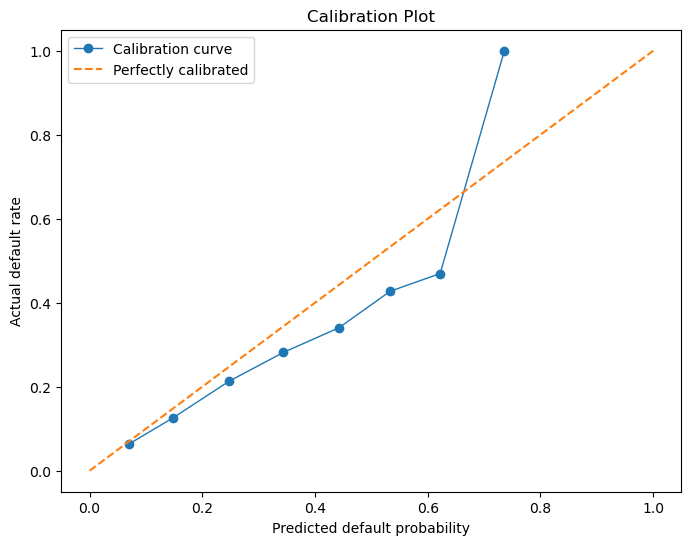

In [50]:
#Calibration plot, comparing predicted default vs actual default rates
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Assuming 'y_true' contains the actual default values and 'y_pred' contains the predicted default probabilities
y_true = test_df["default"]
y_pred = test_df["risk"]

prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted default probability')
plt.ylabel('Actual default rate')
plt.title('Calibration Plot')
plt.legend()
plt.show()


In [52]:
before = test_df["default"].mean() * 1000
after = top["default_rate_after"] * 1000
fig = go.Figure(go.Bar(x=["Current policy", "New policy"], y=[before, after],
                       text=[f"{before:.0f}", f"{after:.0f}"], textposition="outside",
                       marker_color=["gray", "green"]))
fig.update_layout(title="Defaults per 1,000 approved loans")
fig.show()